# Stage1 - Data Pre porcessing

*   Convert BMP to JPG and rescale images






In [ ]:
import os, glob
import pandas as pd

DATA_ROOT = "/content/drive/MyDrive/Research data/sampledata"

VALID_EXT = {".bmp", ".jpg", ".jpeg", ".png", ".webp"}

def collect_paths(root):
    rows = []
    for grade in ["OP", "BOP"]:  # <-- only these two are used
        grade_dir = os.path.join(root, grade)
        if not os.path.isdir(grade_dir):
            print("Missing:", grade_dir)
            continue

        for batch in sorted(os.listdir(grade_dir)):
            batch_dir = os.path.join(grade_dir, batch)
            if not os.path.isdir(batch_dir):
                continue

            for p in glob.glob(os.path.join(batch_dir, "*")):
                ext = os.path.splitext(p)[1].lower()
                if ext in VALID_EXT:
                    rows.append({"path": p, "grade": grade, "batch": batch})

    return pd.DataFrame(rows)

df = collect_paths(DATA_ROOT)
print(df["grade"].value_counts())
df.head()



grade
OP     469
BOP    333
Name: count, dtype: int64


,path,grade,batch
0,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
1,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
2,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
3,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
4,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37


In [ ]:
print("Total images:", len(df))
print(df.sample(5)[["grade","batch","path"]])


Total images: 802
    grade        batch                                               path
709   BOP  BOP_BOP1_41  /content/drive/MyDrive/Research data/sampledat...
543   BOP  BOP_BOP1_37  /content/drive/MyDrive/Research data/sampledat...
44     OP        OP_37  /content/drive/MyDrive/Research data/sampledat...
185    OP        OP_39  /content/drive/MyDrive/Research data/sampledat...
420    OP        OP_43  /content/drive/MyDrive/Research data/sampledat...


In [ ]:
import os, glob, cv2
from tqdm import tqdm

SRC_ROOT = "/content/drive/MyDrive/Research data/sampledata"
DST_ROOT = "/content/drive/MyDrive/Research data/sampledata_jpg"

MAX_SIDE = 1024      # recommended
JPG_QUALITY = 95

def ensure_dir(p): os.makedirs(p, exist_ok=True)

def resize_keep_aspect(img, max_side=1024):
    h, w = img.shape[:2]
    if max(h, w) <= max_side:
        return img
    scale = max_side / max(h, w)
    return cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)

ok, fail = 0, 0

for grade in ["OP", "BOP"]:  # <-- Cat is ignored automatically
    grade_dir = os.path.join(SRC_ROOT, grade)
    for batch in sorted(os.listdir(grade_dir)):
        src_batch = os.path.join(grade_dir, batch)
        if not os.path.isdir(src_batch):
            continue

        dst_batch = os.path.join(DST_ROOT, grade, batch)
        ensure_dir(dst_batch)

        bmp_files = glob.glob(os.path.join(src_batch, "*.bmp"))
        for p in tqdm(bmp_files, desc=f"Converting {grade}/{batch}"):
            img = cv2.imread(p)
            if img is None:
                fail += 1
                continue
            img = resize_keep_aspect(img, MAX_SIDE)

            out_name = os.path.splitext(os.path.basename(p))[0] + ".jpg"
            out_path = os.path.join(dst_batch, out_name)

            if cv2.imwrite(out_path, img, [int(cv2.IMWRITE_JPEG_QUALITY), JPG_QUALITY]):
                ok += 1
            else:
                fail += 1

print("✅ Converted:", ok)
print("❌ Failed:", fail)
print("Output:", DST_ROOT)


Converting BOP/BOP_BOP1_46: 100%|██████████| 15/15 [00:35<00:00,  2.39s/it]

✅ Converted: 802
❌ Failed: 0
Output: /content/drive/MyDrive/Research data/sampledata_jpg


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/Research data/sampledata_jpg"


# Stage2: Build the “Feature Engineering Dataset”

In [ ]:
import os, glob
import pandas as pd

VALID_EXT = {".jpg", ".jpeg", ".png", ".webp"}

def collect_paths(root):
    rows = []
    for grade in ["OP", "BOP"]:
        grade_dir = os.path.join(root, grade)
        for batch in sorted(os.listdir(grade_dir)):
            batch_dir = os.path.join(grade_dir, batch)
            if not os.path.isdir(batch_dir):
                continue
            for p in glob.glob(os.path.join(batch_dir, "*")):
                if os.path.splitext(p)[1].lower() in VALID_EXT:
                    rows.append({"path": p, "grade": grade, "batch": batch})
    return pd.DataFrame(rows)

df = collect_paths(DATA_ROOT)
print(df["grade"].value_counts())
df.head()
 # creates the dataset manifest (preprocessing step)

grade
OP     469
BOP    333
Name: count, dtype: int64


,path,grade,batch
0,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
1,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
2,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
3,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37
4,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37


ROI extraction (remove background + crop to tea)

In [ ]:
import cv2, numpy as np

def extract_tea_roi_and_crop(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # remove background (white)
    _, mask = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)

    # clean noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # crop to tea bounding box
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img, mask

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    tea_crop  = img[y1:y2+1, x1:x2+1]
    mask_crop = mask[y1:y2+1, x1:x2+1]
    return tea_crop, mask_crop


# **Feature extraction functions (5 sensory proxies)**

In [ ]:
!pip -q install scikit-image

import cv2, numpy as np
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

def tea_mask_otsu(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:,:,0]

    # Otsu threshold on L (tea is darker -> inverse)
    _, m = cv2.threshold(L, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # clean mask
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=2)

    # remove tiny specks
    num, lab2, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros_like(m)
    for i in range(1, num):
        if stats[i, cv2.CC_STAT_AREA] > 500:
            keep[lab2 == i] = 255

    return keep.astype(bool)

def blackness_feature_v2(img_bgr, mask):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:,:,0]
    a = lab[:,:,1] - 128.0
    b = lab[:,:,2] - 128.0

    bg = ~mask
    # background white reference
    L_bg = np.median(L[bg]) if bg.sum() > 1000 else np.median(L)

    # normalize illumination (tea darkness relative to background)
    L_norm = np.clip(L / (L_bg + 1e-6) * 255.0, 0, 255)
    darkness = 1.0 - (np.mean(L_norm[mask]) / 255.0)

    # penalize brownness using chroma (optional but helps)
    chroma = np.sqrt(a*a + b*b)
    chroma_mean = np.mean(chroma[mask])
    chroma_norm = np.clip(chroma_mean / 80.0, 0, 1)  # 80 is a reasonable scale

    blackness = darkness * (1.0 - 0.5 * chroma_norm)
    return float(np.clip(blackness, 0, 1))

def twist_feature_v2(img_bgr, mask):
    m = mask.astype(np.uint8)

    # skeleton length density
    sk = skeletonize(m > 0)
    sk_len = float(sk.sum())
    area = float(m.sum()) + 1e-6
    sk_density = sk_len / area

    # component slenderness (major/minor axis ratio)
    lbl = label(m > 0, connectivity=2)
    ratios = []
    for r in regionprops(lbl):
        if r.area < 400:
            continue
        if r.minor_axis_length > 1:
            ratios.append(r.major_axis_length / r.minor_axis_length)
    aspect = float(np.median(ratios)) if ratios else 1.0

    # normalize to 0..1
    sk_norm = np.clip((sk_density - 0.01) / 0.05, 0, 1)
    asp_norm = np.clip((aspect - 3.0) / 10.0, 0, 1)

    twist = 0.6 * sk_norm + 0.4 * asp_norm
    return float(np.clip(twist, 0, 1))


In [ ]:


def evenness_feature(tea, roi):
    gray = cv2.cvtColor(tea, cv2.COLOR_BGR2GRAY)
    return float(1 / (1 + np.var(gray[roi])))

def bloom_feature(tea, roi):
    hsv = cv2.cvtColor(tea, cv2.COLOR_BGR2HSV)
    V, S = hsv[:,:,2], hsv[:,:,1]
    highlight = (V > 200) & (S < 40)
    return float(np.sum(highlight & roi) / roi.sum())

def cleanliness_feature(tea, roi):
    gray = cv2.cvtColor(tea, cv2.COLOR_BGR2GRAY).astype(np.float32)
    vals = gray[roi]

    mu = float(np.mean(vals))
    sigma = float(np.std(vals) + 1e-6)

    outliers = np.sum(np.abs(vals - mu) > 2*sigma)
    noise_ratio = outliers / len(vals)

    cleanliness = 1 - noise_ratio
    return float(np.clip(cleanliness, 0.0, 1.0))



In [ ]:
#Run feature extraction for ALL images (fast + progress bar)

from tqdm import tqdm
import numpy as np
import cv2

def extract_features_from_path(path):
    img = cv2.imread(path)
    if img is None:
        return None

    # keep your crop (so all images are consistent size/ROI area)
    tea, _ = extract_tea_roi_and_crop(img)

    # NEW: stable mask from tea crop (instead of old mask)
    mask = tea_mask_otsu(tea)
    roi = mask

    if roi.sum() < 500:   # require enough tea pixels
        return None

    # NEW: improved blackness + twist
    b  = blackness_feature_v2(tea, roi)
    t  = twist_feature_v2(tea, roi)

    # keep the rest as you had
    e  = evenness_feature(tea, roi)
    bl = bloom_feature(tea, roi)
    c  = cleanliness_feature(tea, roi)

    return b, t, e, bl, c

features = []
keep_idx = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    f = extract_features_from_path(row["path"])
    if f is None:
        continue
    keep_idx.append(i)
    features.append(f)

df2 = df.loc[keep_idx].copy()
df2[["blackness","twist","evenness","bloom","cleanliness"]] = np.array(features)

print("Final rows:", df2.shape)
df2.head()


100%|██████████| 802/802 [04:45<00:00,  2.81it/s]

Final rows: (802, 8)


,path,grade,batch,blackness,twist,evenness,bloom,cleanliness
0,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.714083,0.130768,0.000803,0.004111,0.960973
1,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.714403,0.184420,0.000753,0.005555,0.963224
2,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.693081,0.290239,0.000656,0.011209,0.962746
3,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.698036,0.330972,0.000656,0.011587,0.962845
4,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.680657,0.243627,0.000629,0.011263,0.963421


In [ ]:
OUT_CSV = "/content/drive/MyDrive/Research data/TeaAI_featuresV2.csv"
df2.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)


Saved: /content/drive/MyDrive/Research data/TeaAI_featuresV2.csv


In [ ]:
df2[["blackness","twist","evenness","bloom","cleanliness"]].describe()


,blackness,twist,evenness,bloom,cleanliness
count,802.000000,802.000000,802.000000,802.000000,802.000000
mean,0.684811,0.315504,0.000693,0.013146,0.961374
std,0.052102,0.099143,0.000186,0.008311,0.003855
min,0.503313,0.014259,0.000394,0.000188,0.940110
25%,0.653860,0.246340,0.000578,0.007257,0.960402
50%,0.689086,0.320350,0.000651,0.011189,0.962285
75%,0.720647,0.381109,0.000763,0.016964,0.963693
max,0.804571,0.617236,0.002054,0.052494,0.970441


In [ ]:
df2.groupby("grade")[["blackness","twist","evenness","bloom","cleanliness"]].mean()


,blackness,twist,evenness,bloom,cleanliness
grade,,,,,
BOP,0.681664,0.320234,0.000686,0.012860,0.961503
OP,0.687046,0.312145,0.000699,0.013349,0.961282


# Stage 3 — Discover Structure (Clustering + Visualization)

In [ ]:
#Standardize features
from sklearn.preprocessing import StandardScaler

feat_cols = ["blackness","twist","evenness","bloom","cleanliness"]
X = df2[feat_cols].values
Xz = StandardScaler().fit_transform(X)


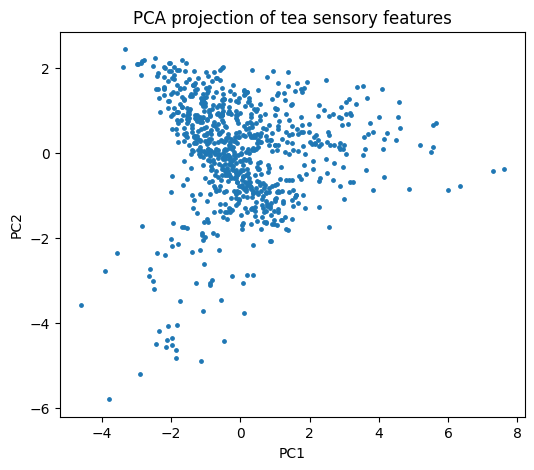

In [ ]:
#PCA plot (see if groups exist)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xz)

plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,1], s=6)
plt.title("PCA projection of tea sensory features")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [ ]:
#Pick K using silhouette (scientific choice)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

scores = []
Ks = range(2, 7)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xz)
    scores.append(silhouette_score(Xz, labels))

for k, s in zip(Ks, scores):
    print(k, "silhouette:", round(s, 4))


2 silhouette: 0.4421
3 silhouette: 0.3324
4 silhouette: 0.3555
5 silhouette: 0.3282
6 silhouette: 0.295


In [ ]:
#Train clustering + inspect what clusters mean
best_k = Ks[int(np.argmax(scores))]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df2["cluster"] = kmeans.fit_predict(Xz)

# cluster profiles (mean of each feature)
cluster_profile = df2.groupby("cluster")[feat_cols].mean().sort_index()
cluster_profile


,blackness,twist,evenness,bloom,cleanliness
cluster,,,,,
0,0.694118,0.307892,0.000660,0.013945,0.961160
1,0.569716,0.409638,0.001102,0.003262,0.964018


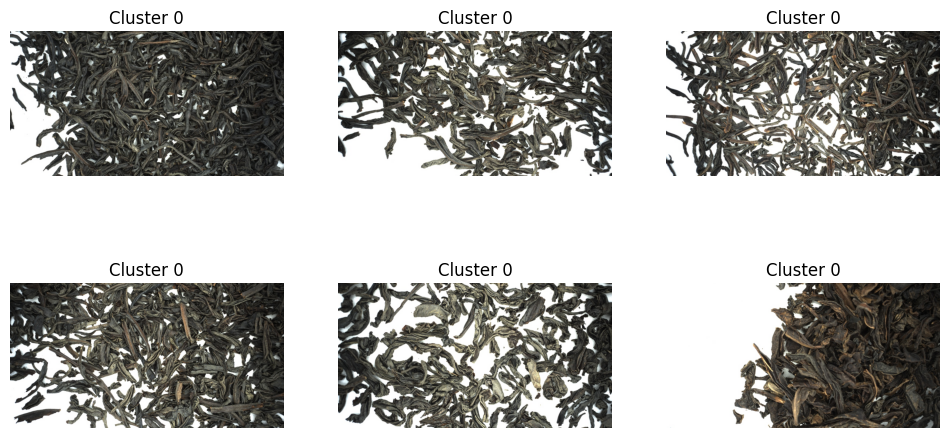

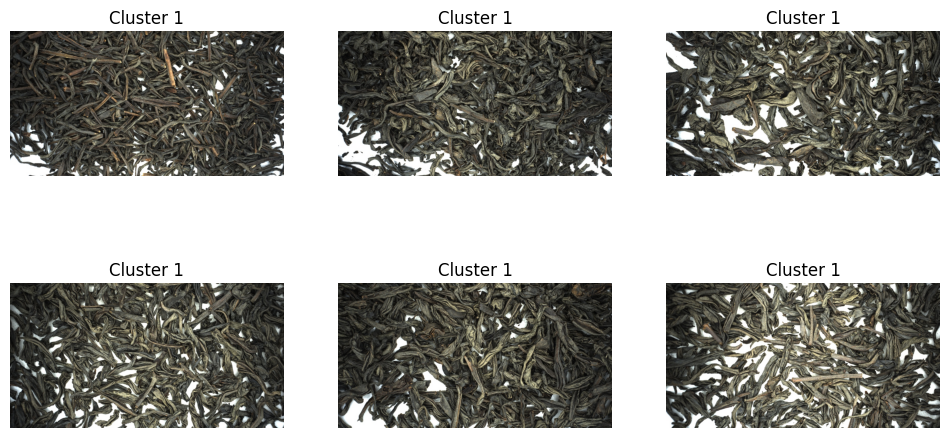

In [ ]:
import random, cv2
import matplotlib.pyplot as plt

def show_cluster_examples(cluster_id, n=6):
    sample_paths = df2[df2["cluster"]==cluster_id]["path"].sample(n, random_state=42).tolist()
    plt.figure(figsize=(12,6))
    for i, p in enumerate(sample_paths):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"Cluster {cluster_id}")
        plt.axis("off")
    plt.show()

for cid in sorted(df2["cluster"].unique()):
    show_cluster_examples(cid, n=6)


In [ ]:
#Create ordinal labels per feature

import pandas as pd

feat_cols = ["blackness","twist","evenness","bloom","cleanliness"]

for col in feat_cols:
    df2[col + "_label"] = pd.qcut(df2[col], q=3, labels=[0,1,2]).astype(int)

df2[[c+"_label" for c in feat_cols]].head()



,blackness_label,twist_label,evenness_label,bloom_label,cleanliness_label
0,2,0,2,0,0
1,2,0,2,0,1
2,1,1,1,1,1
3,1,1,1,1,1
4,1,0,1,1,2


In [ ]:
for col in feat_cols:
    print(col, df2[col+"_label"].value_counts().sort_index().to_dict())


blackness {0: 268, 1: 267, 2: 267}
twist {0: 267, 1: 268, 2: 267}
evenness {0: 268, 1: 266, 2: 268}
bloom {0: 267, 1: 267, 2: 268}
cleanliness {0: 268, 1: 267, 2: 267}


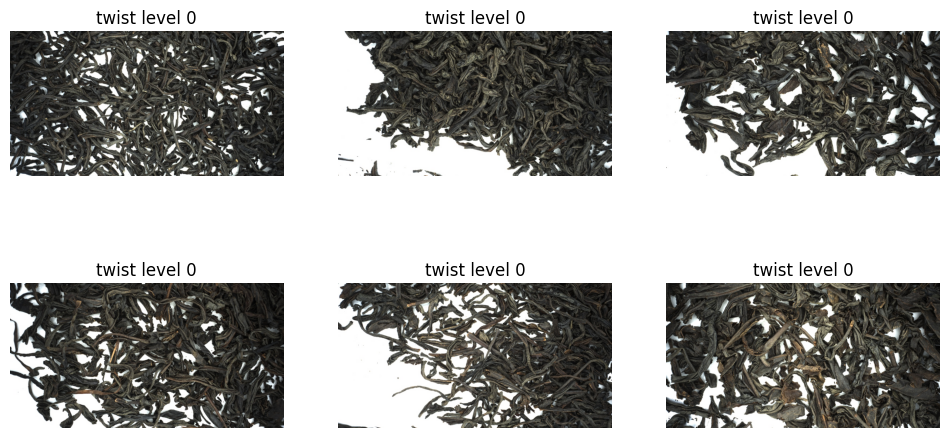

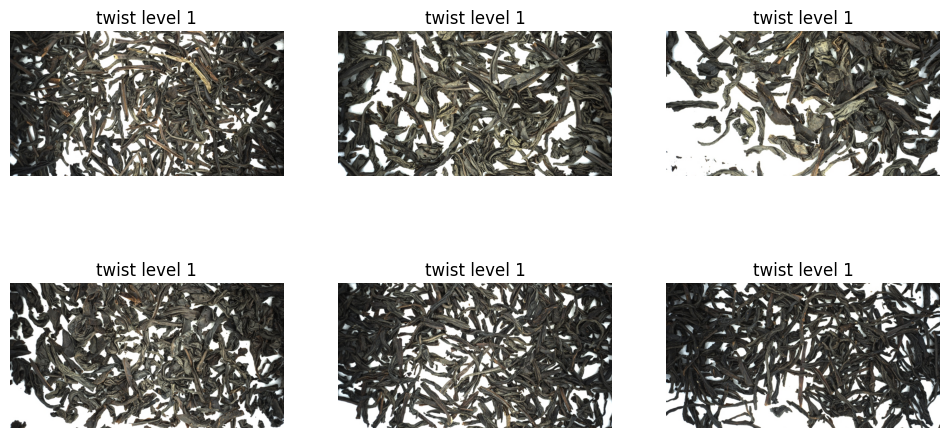

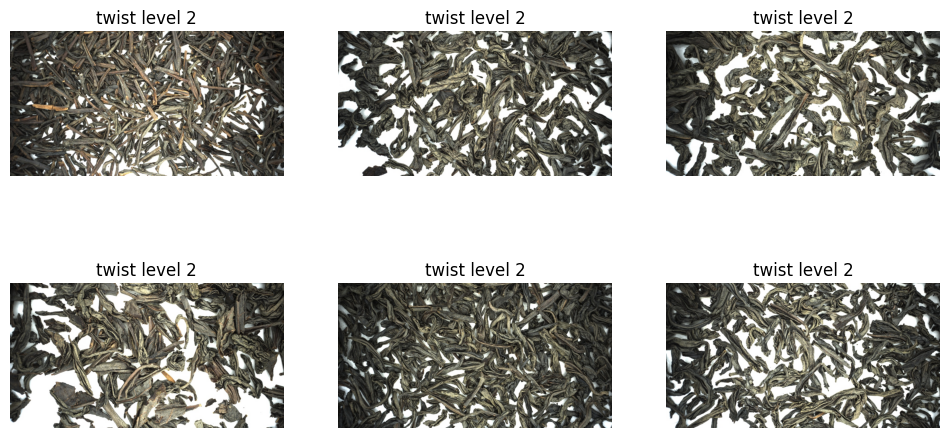

In [ ]:
#This is how you prove to your supervisor that labels make sense visually.
#Example for twist:

import matplotlib.pyplot as plt
import cv2

def show_examples_for_attribute(attr, level, n=6):
    subset = df2[df2[attr + "_label"] == level].sample(n, random_state=42)
    plt.figure(figsize=(12,6))
    for i, p in enumerate(subset["path"].tolist()):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"{attr} level {level}")
        plt.axis("off")
    plt.show()

for lvl in [0,1,2]:
    show_examples_for_attribute("twist", lvl)


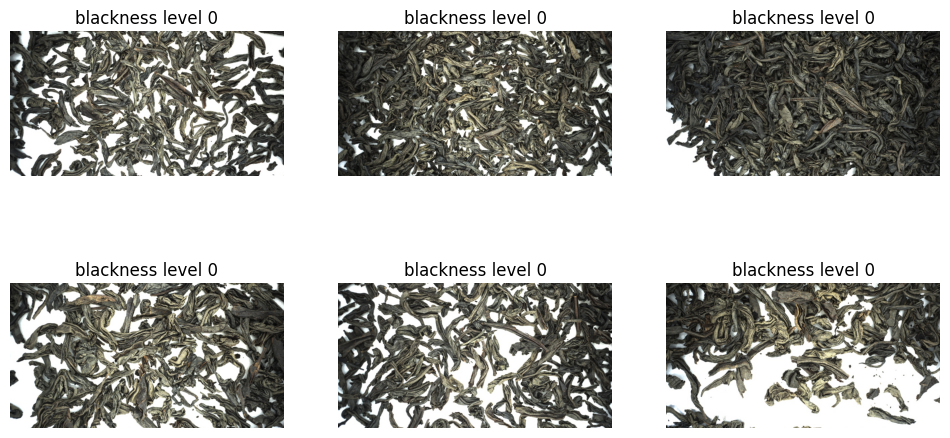

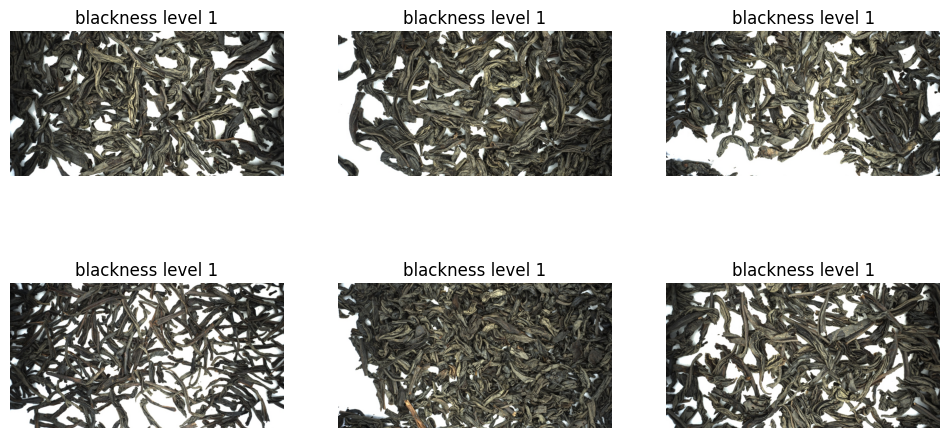

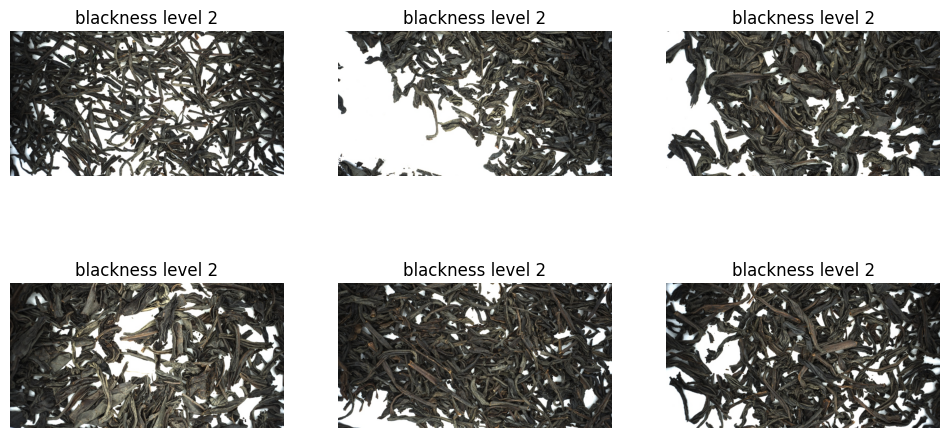

In [ ]:
##Example for Blackness:

import matplotlib.pyplot as plt
import cv2

def show_examples_for_attribute(attr, level, n=6):
    subset = df2[df2[attr + "_label"] == level].sample(n, random_state=42)
    plt.figure(figsize=(12,6))
    for i, p in enumerate(subset["path"].tolist()):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"{attr} level {level}")
        plt.axis("off")
    plt.show()

for lvl in [0,1,2]:
    show_examples_for_attribute("blackness", lvl)


In [ ]:
#Map ordinal labels to human words (this becomes your model output)
label_words = {
  "blackness":   {0:"light", 1:"moderately black", 2:"very black"},
  "twist":       {0:"loose", 1:"moderately twisted", 2:"well-twisted / wiry"},
  "evenness":    {0:"uneven",1:"moderately even", 2:"even"},
  "bloom":       {0:"low bloom", 1:"moderate bloom", 2:"high bloom"},
  "cleanliness": {0:"less clean", 1:"clean", 2:"very clean"}
}


# **Cell 1 — Create ordinal labels (0/1/2) per attribute**

What it does: converts continuous feature values into 3 levels.

In [ ]:
import pandas as pd

feat_cols = ["blackness","twist","evenness","bloom","cleanliness"]

for col in feat_cols:
    df2[col+"_label"] = pd.qcut(df2[col], q=3, labels=[0,1,2]).astype(int)

# quick check: should be near-balanced
for col in feat_cols:
    print(col, df2[col+"_label"].value_counts().sort_index().to_dict())


blackness {0: 268, 1: 267, 2: 267}
twist {0: 267, 1: 268, 2: 267}
evenness {0: 268, 1: 266, 2: 268}
bloom {0: 267, 1: 267, 2: 268}
cleanliness {0: 268, 1: 267, 2: 267}


# **Cell 2 — Create Train/Val/Test split (IMPORTANT: split by batch)**

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

feat_cols = ["blackness", "twist", "evenness", "bloom", "cleanliness"]
target_cols = [c + "_label" for c in feat_cols]

# Paths
X_paths = df2["path"].astype(str).values

# Labels as int32 (VERY important)
y = df2[target_cols].astype(np.int32).values

# Batch groups
groups = df2["batch"].astype(str).values  # prevents leakage

# 80/20 train-test split by batch
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_paths, y, groups=groups))

X_train, X_test = X_paths[train_idx], X_paths[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

# 80/20 train-val split by batch again (so val is also clean)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, val_idx = next(gss2.split(X_train, y_train, groups=groups_train))

X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print("Train:", len(X_tr), "Val:", len(X_val), "Test:", len(X_test))
print("Unique batches -> Train:", len(set(groups_train[tr_idx])),
      "Val:", len(set(groups_train[val_idx])),
      "Test:", len(set(groups[test_idx])))


Train: 441 Val: 163 Test: 198
Unique batches -> Train: 6 Val: 2 Test: 2


# **Cell 3 — Build tf.data pipeline (fast, scalable, correct)**

We now create a dataset loader that:

*  reads JPG
*  resizes
*  normalizes
*  (optional) augmentation for robustness


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH = 32

def load_image(path):
    img_bytes = tf.io.read_file(path)

    # Robust: works even if some images are PNG/JPG
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def augment(img):
    # Light augmentations (keep tea structure realistic)
    img = tf.image.random_brightness(img, 0.06)
    img = tf.image.random_contrast(img, 0.90, 1.10)
    img = tf.image.random_saturation(img, 0.90, 1.10)

    # Small random flip is usually OK because tea texture is not directional
    img = tf.image.random_flip_left_right(img)
    return img

def make_ds(X, y, training=False):
    X = tf.convert_to_tensor(X, dtype=tf.string)
    y = tf.convert_to_tensor(y, dtype=tf.int32)  # force int32

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(min(len(X), 2000), reshuffle_each_iteration=True)

    def _map(path, labels):
        img = load_image(path)
        if training:
            img = augment(img)

        # Ensure each head label is scalar int32
        labels = tf.cast(labels, tf.int32)

        out = {
            "blackness":   labels[0],
            "twist":       labels[1],
            "evenness":    labels[2],
            "bloom":       labels[3],
            "cleanliness": labels[4],
        }
        return img, out

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_tr, y_tr, training=True)
val_ds   = make_ds(X_val, y_val, training=False)
test_ds  = make_ds(X_test, y_test, training=False)


# Cell 4 — Build TeaSensoryNet (CUSTOM CNN, no pretrained)

In [ ]:
from tensorflow.keras import layers, Model, regularizers

def conv_block(x, filters, k=3, s=1, drop=0.0):
    x = layers.Conv2D(filters, k, strides=s, padding="same",
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if drop > 0:
        x = layers.Dropout(drop)(x)
    return x

def build_backbone(input_shape=(224,224,3)):
    inp = layers.Input(shape=input_shape)

    x = conv_block(inp, 32)
    x = conv_block(x, 32)
    x = layers.MaxPooling2D()(x)

    x = conv_block(x, 64)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D()(x)

    x = conv_block(x, 128)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D()(x)

    x = conv_block(x, 256)
    x = conv_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    return Model(inp, x, name="TeaBackbone")

def build_teasensorynet():
    backbone = build_backbone((IMG_SIZE, IMG_SIZE, 3))
    inp = backbone.input
    feat = backbone.output

    outputs = {
        "blackness":   layers.Dense(3, activation="softmax", name="blackness")(feat),
        "twist":       layers.Dense(3, activation="softmax", name="twist")(feat),
        "evenness":    layers.Dense(3, activation="softmax", name="evenness")(feat),
        "bloom":       layers.Dense(3, activation="softmax", name="bloom")(feat),
        "cleanliness": layers.Dense(3, activation="softmax", name="cleanliness")(feat),
    }

    return Model(inp, outputs, name="TeaSensoryNet")

model = build_teasensorynet()
model.summary()


Model: "TeaSensoryNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 224, 224,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 224, 224,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 112, 112,  │     18,432 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 112, 112,  │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 56, 56,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 56, 56,    │     73,728 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_16[0][0] 

 Total params: 1,244,783 (4.75 MB)

 Trainable params: 1,242,863 (4.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

# **Cell 5 — Compile + Train**

In [ ]:
import tensorflow as tf

# ---- (optional) smooth labels without SparseCategoricalCrossentropy(label_smoothing=..) ----
# Works in ANY TF version because we convert sparse -> one-hot inside the loss.
def smooth_sparse_cce(smoothing=0.05, num_classes=3):
    cce = tf.keras.losses.CategoricalCrossentropy(label_smoothing=smoothing)
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes)
        return cce(y_true_oh, y_pred)
    return loss_fn

losses = {
    "blackness":   smooth_sparse_cce(0.05),
    "twist":       smooth_sparse_cce(0.05),
    "evenness":    smooth_sparse_cce(0.03),
    "bloom":       smooth_sparse_cce(0.02),
    "cleanliness": smooth_sparse_cce(0.03),
}

# Focus learning more on blackness + twist
loss_weights = {
    "blackness": 1.6,
    "twist": 1.6,
    "evenness": 1.0,
    "bloom": 0.8,
    "cleanliness": 1.0,
}

metrics = {
    "blackness":   [tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
                    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2")],
    "twist":       [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
    "evenness":    [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
    "bloom":       [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
    "cleanliness": [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

# Monitor the head you care about (twist OR blackness). Here I pick twist.
monitor_metric = "val_twist_acc"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_teasensorynet.keras",
        monitor=monitor_metric,
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor=monitor_metric,
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor_metric,
        mode="max",
        patience=5,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=callbacks
)


Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - blackness_acc: 0.6096 - blackness_loss: 0.8981 - blackness_top2: 0.8387 - bloom_acc: 0.6864 - bloom_loss: 0.7205 - cleanliness_acc: 0.5813 - cleanliness_loss: 0.8888 - evenness_acc: 0.6577 - evenness_loss: 0.7288 - loss: 5.0875 - twist_acc: 0.6238 - twist_loss: 0.8611
Epoch 1: val_twist_acc improved from -inf to 0.28221, saving model to best_teasensorynet.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - blackness_acc: 0.6110 - blackness_loss: 0.8955 - blackness_top2: 0.8408 - bloom_acc: 0.6869 - bloom_loss: 0.7207 - cleanliness_acc: 0.5817 - cleanliness_loss: 0.8898 - evenness_acc: 0.6587 - evenness_loss: 0.7281 - loss: 5.0790 - twist_acc: 0.6262 - twist_loss: 0.8579 - val_blackness_acc: 0.3865 - val_blackness_loss: 1.0941 - val_blackness_top2: 0.7607 - val_bloom_acc: 0.3681 - val_bloom_loss: 1.3537 - val_cleanliness_acc: 0.2515 - val_cleanliness_loss: 1.2171 - val_evenness_acc: 0.3865 - val_evenness_loss: 1.4050 - val_loss: 7.2777 - 

# **Cell 6 — Evaluate on test set**

In [ ]:
test_metrics = model.evaluate(test_ds)
test_metrics


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 631ms/step - blackness_acc: 0.1406 - blackness_loss: 1.1749 - blackness_top2: 0.4963 - bloom_acc: 0.1441 - bloom_loss: 1.2023 - cleanliness_acc: 0.1950 - cleanliness_loss: 1.1265 - evenness_acc: 0.1361 - evenness_loss: 1.3031 - loss: 6.1284 - twist_acc: 0.0978 - twist_loss: 1.2374 - twist_top2: 0.4904


[6.050215244293213,
 1.1743890047073364,
 1.2321157455444336,
 1.2616462707519531,
 1.1709344387054443,
 1.110050916671753,
 0.14141413569450378,
 0.5353535413742065,
 0.18686868250370026,
 0.24747474491596222,
 0.18686868250370026,
 0.1111111119389534,
 0.5404040217399597]

# **Cell 7 — Inference: image → adjectives + confidence (human taster style)**

In [ ]:
label_words = {
  "blackness":   {0:"light", 1:"moderately black", 2:"very black"},
  "twist":       {0:"loose", 1:"moderately twisted", 2:"well-twisted / wiry"},
  "evenness":    {0:"uneven",1:"moderately even", 2:"even"},
  "bloom":       {0:"low bloom", 1:"moderate bloom", 2:"high bloom"},
  "cleanliness": {0:"less clean", 1:"clean", 2:"very clean"}
}

def predict_adjectives(image_path):
    img = load_image(tf.constant(image_path))
    img = tf.expand_dims(img, 0)  # batch dimension

    preds = model.predict(img, verbose=0)  # list of 5 arrays (1,3)
    heads = ["blackness","twist","evenness","bloom","cleanliness"]

    result = {}
    for head, p in zip(heads, preds):
        probs = p[0]
        label = int(tf.argmax(probs).numpy())
        conf = float(tf.reduce_max(probs).numpy())
        result[head] = {"label": label, "adjective": label_words[head][label], "confidence": conf}

    # human taster style description
    desc = (
        f"Leaf appearance is {result['blackness']['adjective']} with {result['twist']['adjective']} structure, "
        f"showing {result['evenness']['adjective']} particle distribution. "
        f"Bloom is {result['bloom']['adjective']}, and overall cleanliness is {result['cleanliness']['adjective']}."
    )
    return desc, result

# Example:
# desc, structured = predict_adjectives(X_test[0])
# print(desc)
# structured


# **Proper testing: Accuracy + Macro F1 + Weighted F1 for each head**

In [ ]:
model.metrics_names


['loss',
 'compile_metrics',
 'blackness_loss',
 'twist_loss',
 'evenness_loss',
 'bloom_loss',
 'cleanliness_loss']

In [ ]:
results = model.evaluate(test_ds, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name:25s}: {val:.4f}")


loss                     : 6.0502
compile_metrics          : 1.1744
blackness_loss           : 1.2321
twist_loss               : 1.2616
evenness_loss            : 1.1709
bloom_loss               : 1.1101
cleanliness_loss         : 0.1414


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

heads = ["blackness","twist","evenness","bloom","cleanliness"]

# -------- collect y_true from test_ds --------
y_true = {h: [] for h in heads}
for _, batch_labels in test_ds:
    for h in heads:
        y_true[h].extend(batch_labels[h].numpy().tolist())

# -------- predict --------
pred = model.predict(test_ds, verbose=0)

# convert pred -> dict(head -> array)
if isinstance(pred, dict):
    pred_dict = {h: np.array(pred[h]) for h in heads}
else:
    pred_dict = {h: np.array(p) for h, p in zip(heads, pred)}

# -------- make y_pred safely --------
y_pred = {}
for h in heads:
    p = pred_dict[h]

    # Expected: (N,3). If (N,), it's already class IDs.
    if p.ndim == 1:
        y_pred[h] = p.astype(int)
    else:
        y_pred[h] = np.argmax(p, axis=-1)

# -------- report --------
for h in heads:
    acc = accuracy_score(y_true[h], y_pred[h])
    f1_macro = f1_score(y_true[h], y_pred[h], average="macro")
    f1_weighted = f1_score(y_true[h], y_pred[h], average="weighted")

    print("\n====================", h.upper(), "====================")
    print("Accuracy     :", round(acc, 4))
    print("F1 Macro     :", round(f1_macro, 4))
    print("F1 Weighted  :", round(f1_weighted, 4))



==================== BLACKNESS ====================
Accuracy     : 0.1414
F1 Macro     : 0.0826
F1 Weighted  : 0.035

==================== TWIST ====================
Accuracy     : 0.1111
F1 Macro     : 0.0667
F1 Weighted  : 0.0222

==================== EVENNESS ====================
Accuracy     : 0.1869
F1 Macro     : 0.105
F1 Weighted  : 0.0588

==================== BLOOM ====================
Accuracy     : 0.1869
F1 Macro     : 0.105
F1 Weighted  : 0.0588

==================== CLEANLINESS ====================
Accuracy     : 0.2475
F1 Macro     : 0.1323
F1 Weighted  : 0.0982


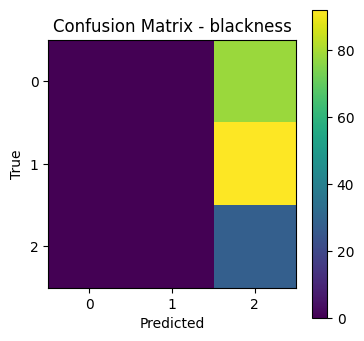

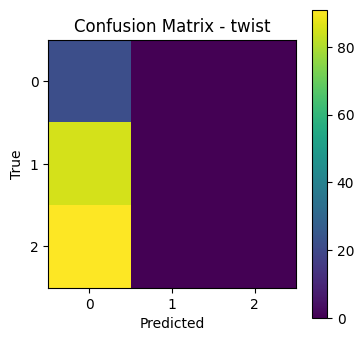

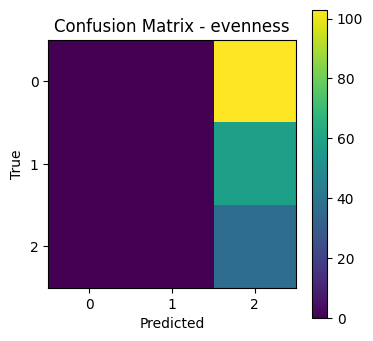

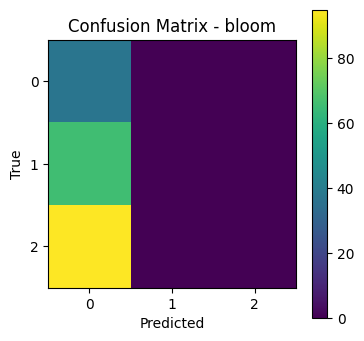

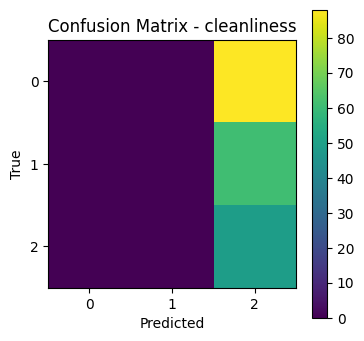

In [ ]:
import matplotlib.pyplot as plt

def plot_cm(cm, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks([0,1,2],[0,1,2])
    plt.yticks([0,1,2],[0,1,2])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

for h in heads:
    cm = confusion_matrix(y_true[h], y_pred[h])
    plot_cm(cm, f"Confusion Matrix - {h}")


In [ ]:
accs, f1s = [], []

for h in heads:
    accs.append(accuracy_score(y_true[h], y_pred[h]))
    f1s.append(f1_score(y_true[h], y_pred[h], average="macro"))

print("Overall mean accuracy (5 heads):", round(float(np.mean(accs)), 4))
print("Overall mean Macro-F1 (5 heads):", round(float(np.mean(f1s)), 4))


Overall mean accuracy (5 heads): 0.1747
Overall mean Macro-F1 (5 heads): 0.0983


In [ ]:
for h in heads:
    mae = np.mean(np.abs(np.array(y_true[h]) - np.array(y_pred[h])))
    print(h, "Ordinal MAE:", round(float(mae), 4))


blackness Ordinal MAE: 0.4242
twist Ordinal MAE: 0.3737
evenness Ordinal MAE: 0.1919
bloom Ordinal MAE: 0.1212
cleanliness Ordinal MAE: 0.4293


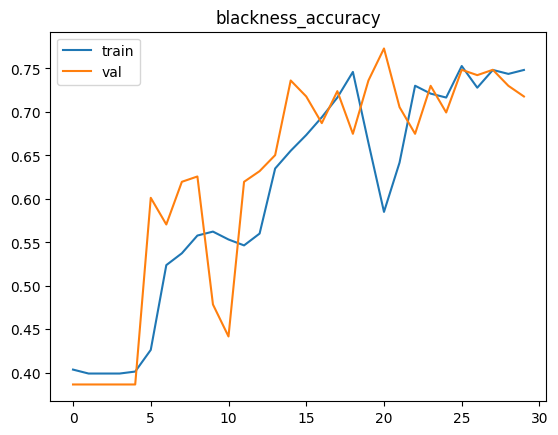

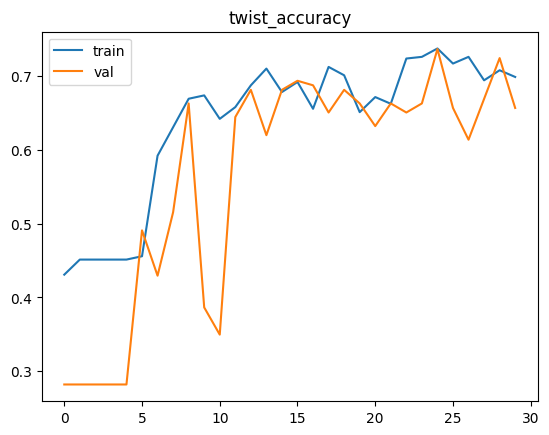

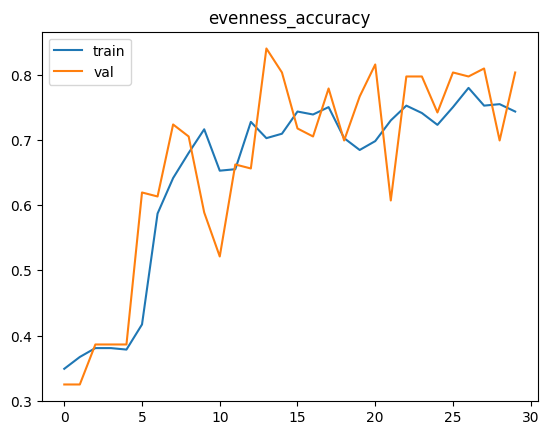

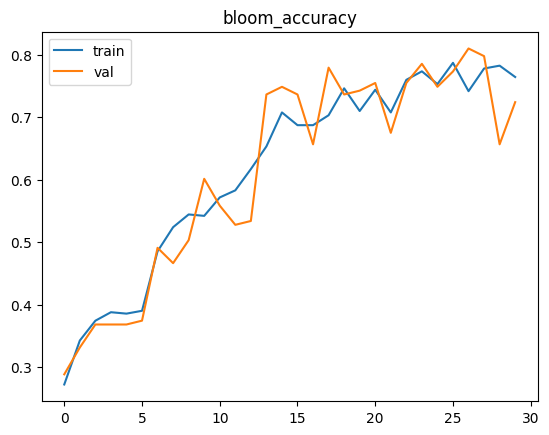

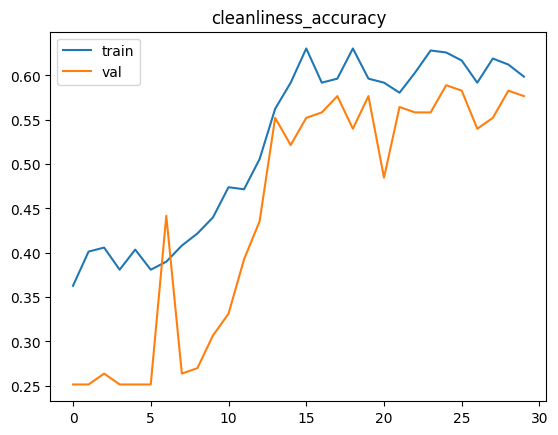

In [ ]:
import matplotlib.pyplot as plt

for k in ["blackness_accuracy","twist_accuracy","evenness_accuracy","bloom_accuracy","cleanliness_accuracy"]:
    plt.figure()
    plt.plot(history.history[k], label="train")
    plt.plot(history.history["val_"+k], label="val")
    plt.title(k)
    plt.legend()
    plt.show()
